# Общие подготовительные действия

In [43]:
import matplotlib.pyplot as plt
import nltk
import pandas as pd
import re
import requests
import seaborn as sns
from bs4 import BeautifulSoup
from math import ceil
from nltk.corpus import stopwords
from nltk.tokenize import WordPunctTokenizer
from pymorphy3 import MorphAnalyzer
from selenium import webdriver
from selenium.common.exceptions import TimeoutException
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.support.ui import WebDriverWait
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import ElasticNetCV, LassoCV, LinearRegression, RidgeCV
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

nltk.download("stopwords")

sns.set_theme()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sosno\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Скрейпинг и парсинг образовательных курсов

In [2]:
tags_ru = ["Программирование", "Веб-разработка", "Машинное обучение", "Базы данных"]
tags_en = ["Programming", "Web Development", "Machine Learning", "Databases"]

## Stepik

In [ ]:
class StepikParser:
    def __init__(self, client_id, client_secret):
        self.session = requests.Session()
        self.session.headers.update(self.get_headers(client_id, client_secret))
    
    def get_headers(self, client_id, client_secret):
        response = self.session.post("https://stepik.org/oauth2/token/", data={
            "grant_type": "client_credentials",
            "client_id": client_id,
            "client_secret": client_secret
        })
        print(response)
        if response.status_code != 200:
            return
        access_token = response.json()["access_token"]
        return {"Authorization": f"Bearer {access_token}"}

    def get_courses(self, queries, pages=10):
        courses_dfs = []
        for query in queries:
            courses = self.get_courses_by_query(query, pages)
            courses.to_csv(f"./Stepik/{query}.csv", index=False)
            courses_dfs.append(courses)
            print()
        return pd.concat(courses_dfs)
    
    def get_courses_by_query(self, query, pages=10):
        courses = []
        page = 1

        while page <= pages:
            response = self.session.get(
                "https://stepik.org/api/search-results",
                params={"query": query, "page": page}
            )
            if response.status_code != 200:
                print(f"Ошибка: {response}")
                break
            response_json = response.json()

            meta = response_json["meta"]
            if page == 1:
                print(f"Поиск курсов по запросу: {query}. Результатов: {meta["count"]}")

            search_results = response_json["search-results"]
            print(f"Получение {len(search_results)} курсов со страницы {page}...")

            courses_ids = [result["course"] for result in search_results]
            courses.extend(self.get_courses_by_ids(courses_ids, query))

            if not meta["has_next"]:
                break
            page += 1
        
        print(f"Успешно получено {len(courses)} курсов")
        return pd.DataFrame(courses)
    
    def get_courses_by_ids(self, courses_ids, tag):
        response = self.session.get(
            "https://stepik.org/api/courses",
            params={"ids[]": courses_ids}
        )
        if response.status_code != 200:
            print(f"Ошибка: {response}")
            return
        courses = response.json()["courses"]
        return [self.parse_course_info(course, tag) for course in courses]

    def parse_course_info(self, course, tag):
        course_info = {
            "platform": "Stepik",
            "tag": tag,
            "url": course["canonical_url"],
            "title": course["title"],
            "summary": course["summary"],
            "language": course["language"],
            "difficulty": course["difficulty"],
            "learners_count": course["learners_count"],
            "price": course["display_price"]
        }

        if course["with_certificate"]:
            course_info["certificate"] = "Certificate"
        else:
            course_info["certificate"] = None

        authors_ids = [id for id in course["authors"]]
        course_info["authors"] = self.get_course_authors_by_ids(authors_ids)

        rating, reviews_count = self.get_course_reviews_info(course["id"])
        course_info["rating"] = rating
        course_info["reviews_count"] = reviews_count

        return course_info

    def get_course_authors_by_ids(self, authors_ids):
        response = self.session.get(
            "https://stepik.org/api/users",
            params={"ids[]": authors_ids}
        )
        if response.status_code != 200:
            print(f"Ошибка: {response}")
            return
        authors = response.json()["users"]
        return ";".join([author["full_name"] for author in authors])
    
    def get_course_reviews_info(self, course_id):
        response = self.session.get(
            f"https://stepik.org/api/course-review-summaries",
            params={"course": course_id}
        )
        if response.status_code != 200:
            print(f"Ошибка: {response}")
            return
        summary = response.json()["course-review-summaries"][0]
        return summary["average"], summary["count"]


stepik_parser = StepikParser(client_id="", client_secret="")

<Response [200]>


In [60]:
(stepik_courses_by_tags_ru := stepik_parser.get_courses(tags_ru))

Поиск курсов по запросу: Программирование. Результатов: 199
Получение 20 курсов со страницы 1...
Получение 20 курсов со страницы 2...
Получение 20 курсов со страницы 3...
Получение 20 курсов со страницы 4...
Получение 20 курсов со страницы 5...
Получение 20 курсов со страницы 6...
Получение 20 курсов со страницы 7...
Получение 20 курсов со страницы 8...
Получение 20 курсов со страницы 9...
Получение 19 курсов со страницы 10...
Успешно получено 199 курсов

Поиск курсов по запросу: Веб-разработка. Результатов: 198
Получение 20 курсов со страницы 1...
Получение 20 курсов со страницы 2...
Получение 20 курсов со страницы 3...
Получение 20 курсов со страницы 4...
Получение 20 курсов со страницы 5...
Получение 20 курсов со страницы 6...
Получение 20 курсов со страницы 7...
Получение 20 курсов со страницы 8...
Получение 20 курсов со страницы 9...
Получение 18 курсов со страницы 10...
Успешно получено 198 курсов

Поиск курсов по запросу: Машинное обучение. Результатов: 196
Получение 20 курсов с

,platform,tag,url,title,summary,language,difficulty,learners_count,price,certificate,authors,rating,reviews_count
0,Stepik,Программирование,https://stepik.org/course/256643/,ООП Python: Часть 1,Часть 1: Фундамент ООП. Научитесь мыслить объе...,ru,normal,2894,-,Certificate,Александр Заплавный,4.945652,92
1,Stepik,Программирование,https://stepik.org/course/227627/,Лучший по Python. Часть 3,Продолжение легендарной 1 части!\r\n\r\nКурс у...,ru,normal,971,2100 ₽,Certificate,Иван Стародубцев;Ksenia Pylkina,4.984127,126
2,Stepik,Программирование,https://stepik.org/course/221885/,Лучший по Python. Часть 2,Продолжение легендарной 1 части!\n\nКурс уника...,ru,easy,7914,-,Certificate,Иван Стародубцев,4.960123,978
3,Stepik,Программирование,https://stepik.org/course/214271/,Лучший по Python. Для всех начинающих!,"Самый интересный курс для тех, кто хочет начат...",ru,easy,28632,-,Certificate,Иван Стародубцев,4.953842,3748
4,Stepik,Программирование,https://stepik.org/course/195619/,Функциональное программирование на Python,"🚀 ""Функциональное программирование на Python"" ...",ru,normal,14762,1499 ₽,Certificate,Артем Егоров,4.949239,394
...,...,...,...,...,...,...,...,...,...,...,...,...,...
787,Stepik,Базы данных,https://stepik.org/course/96265/,Базовый курс: Как всё работает в Mindbox,Курс для старта работы в Mindbox. Видеоуроки п...,ru,easy,8401,-,None,Mindbox. Платформа автоматизации маркетинга,4.066667,105
788,Stepik,Базы данных,https://stepik.org/course/60859/,Компьютерные технологии в биологии,21 век отмечен масштабным развитием цифровизац...,ru,easy,5287,-,Certificate,Алтайский государственный университет,5.000000,105
789,Stepik,Базы данных,https://stepik.org/course/53429/,Личностное развитие,"Курс будет полезен для всех, кто хочет разви...",ru,None,80436,-,None,КНИТУ-КАИ им. А. Н. Туполева,4.917197,1570
790,Stepik,Базы данных,https://stepik.org/course/2096/,Поиск средств для НКО,Курс даёт базовое представление об источниках ...,ru,None,10068,3000 ₽,Certificate,Кухня НКО,4.942922,438


In [61]:
(stepik_courses_by_tags_en := stepik_parser.get_courses(tags_en))

Поиск курсов по запросу: Programming. Результатов: 197
Получение 20 курсов со страницы 1...
Получение 20 курсов со страницы 2...
Получение 20 курсов со страницы 3...
Получение 20 курсов со страницы 4...
Получение 20 курсов со страницы 5...
Получение 20 курсов со страницы 6...
Получение 20 курсов со страницы 7...
Получение 20 курсов со страницы 8...
Получение 20 курсов со страницы 9...
Получение 17 курсов со страницы 10...
Успешно получено 197 курсов

Поиск курсов по запросу: Web Development. Результатов: 196
Получение 20 курсов со страницы 1...
Получение 20 курсов со страницы 2...
Получение 20 курсов со страницы 3...
Получение 20 курсов со страницы 4...
Получение 20 курсов со страницы 5...
Получение 20 курсов со страницы 6...
Получение 20 курсов со страницы 7...
Получение 20 курсов со страницы 8...
Получение 20 курсов со страницы 9...
Получение 16 курсов со страницы 10...
Успешно получено 196 курсов

Поиск курсов по запросу: Machine Learning. Результатов: 196
Получение 20 курсов со стр

,platform,tag,url,title,summary,language,difficulty,learners_count,price,certificate,authors,rating,reviews_count
0,Stepik,Programming,https://stepik.org/course/261410/,DevOps-инструменты [ Linux + Docker + Git ],"DevOps-специалист: освойте Linux, Git, Docker ...",ru,easy,119,7270 ₽,Certificate,Rotoro cloud;Pragmatic Programmer,0.000000,0
1,Stepik,Programming,https://stepik.org/course/253025/,IT-фундамент [ SQL + Linux + Git ],"На каком бы языке Вы ни программировали, вероя...",ru,None,38,4000 ₽,Certificate,Pragmatic Programmer,5.000000,1
2,Stepik,Programming,https://stepik.org/course/241839/,Профессия: Python-разработчик [ Python + SQL +...,Учебная программа даст все необходимые навыки:...,ru,easy,97,8500 ₽,Certificate,Pragmatic Programmer;Future People,5.000000,1
3,Stepik,Programming,https://stepik.org/course/230401/,"Сохрани меня, если сможешь: модули и файлы в P...",🚀 «Модули и файлы в Python: легко и понятно» —...,ru,normal,3415,-,Certificate,Артем Егоров,5.000000,28
4,Stepik,Programming,https://stepik.org/course/220674/,Твой Golang,Твой Golang — это идеальный старт для освоения...,ru,easy,6960,-,Certificate,Павел Тарасов,4.979310,145
...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,Stepik,Databases,https://stepik.org/course/174887/,Практический Тренажер по PHP,Курс включает в себя разнообразные практически...,ru,normal,217,1399 ₽,Certificate,IT Guru,5.000000,3
778,Stepik,Databases,https://stepik.org/course/130681/,Тестирование на практике — подготовка к собесе...,Здесь я узнаю:\r\n\r\nКак создать правильное р...,ru,normal,4289,500 ₽,Certificate,Камиль Сабуев;Владимир Халяпин,4.500000,8
779,Stepik,Databases,https://stepik.org/course/125840/,Astra Linux для пользователя,В курсе рассказывается об отечественной операц...,ru,easy,4174,-,None,Khasan Sadretdinov,4.421875,128
780,Stepik,Databases,https://stepik.org/course/108869/,Информатика 11 класс к учебнику Полякова К.Ю. ...,Курс создан для преподавания информатики в 11 ...,ru,None,2093,-,None,Салтыков Виктор,0.000000,0


In [ ]:
stepik_courses = pd.concat([stepik_courses_by_tags_ru, stepik_courses_by_tags_en], ignore_index=True)
stepik_courses.to_csv("Stepik.csv", index=False)
stepik_courses

,platform,tag,url,title,summary,language,difficulty,learners_count,price,certificate,authors,rating,reviews_count
0,Stepik,Программирование,https://stepik.org/course/256643/,ООП Python: Часть 1,Часть 1: Фундамент ООП. Научитесь мыслить объе...,ru,normal,2894,-,Certificate,Александр Заплавный,4.945652,92
1,Stepik,Программирование,https://stepik.org/course/227627/,Лучший по Python. Часть 3,Продолжение легендарной 1 части!\r\n\r\nКурс у...,ru,normal,971,2100 ₽,Certificate,Иван Стародубцев;Ksenia Pylkina,4.984127,126
2,Stepik,Программирование,https://stepik.org/course/221885/,Лучший по Python. Часть 2,Продолжение легендарной 1 части!\n\nКурс уника...,ru,easy,7914,-,Certificate,Иван Стародубцев,4.960123,978
3,Stepik,Программирование,https://stepik.org/course/214271/,Лучший по Python. Для всех начинающих!,"Самый интересный курс для тех, кто хочет начат...",ru,easy,28632,-,Certificate,Иван Стародубцев,4.953842,3748
4,Stepik,Программирование,https://stepik.org/course/195619/,Функциональное программирование на Python,"🚀 ""Функциональное программирование на Python"" ...",ru,normal,14762,1499 ₽,Certificate,Артем Егоров,4.949239,394
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1569,Stepik,Databases,https://stepik.org/course/174887/,Практический Тренажер по PHP,Курс включает в себя разнообразные практически...,ru,normal,217,1399 ₽,Certificate,IT Guru,5.000000,3
1570,Stepik,Databases,https://stepik.org/course/130681/,Тестирование на практике — подготовка к собесе...,Здесь я узнаю:\r\n\r\nКак создать правильное р...,ru,normal,4289,500 ₽,Certificate,Камиль Сабуев;Владимир Халяпин,4.500000,8
1571,Stepik,Databases,https://stepik.org/course/125840/,Astra Linux для пользователя,В курсе рассказывается об отечественной операц...,ru,easy,4174,-,None,Khasan Sadretdinov,4.421875,128
1572,Stepik,Databases,https://stepik.org/course/108869/,Информатика 11 класс к учебнику Полякова К.Ю. ...,Курс создан для преподавания информатики в 11 ...,ru,None,2093,-,None,Салтыков Виктор,0.000000,0


## Alison

In [45]:
class AlisonParser:
    def __init__(self):
        chrome_options = Options()
        self.driver = webdriver.Chrome(options=chrome_options)
        self.driver.set_page_load_timeout(10)
        self.driver.implicitly_wait(10)

    def get_queries_by_tag(self, tag, start_page=1, end_page=None):
        result = None
        page = start_page
        while end_page is None or page <= end_page:
            try:
                url_tag = tag.lower().replace(" ", "-")
                self.driver.get(f"https://alison.com/tag/{url_tag}?&page={page}")
                wait = WebDriverWait(self.driver, 5)
                wait.until(
                    EC.presence_of_element_located((
                        By.CLASS_NAME, "courses__inner"
                    ))
                )
            except TimeoutException:
                self.driver.execute_script("window.stop();")
            
            soup = BeautifulSoup(self.driver.page_source, "html.parser")
            if page == start_page:
                courses_count = int(soup.find(
                    "span", class_="course__info-amount"
                ).text)
                print(
                    f"Поиск курсов по тегу: {tag}. Результатов: {courses_count}"
                )
                if end_page is None:
                    end_page = ceil(courses_count / 16)
            
            courses_block = soup.find("div", class_="courses__inner")
            cards = courses_block.find_all("div", class_="card")
            if cards:
                print(f"Получение {len(cards)} курсов со страницы {page}...")
            else:
                print("Больше нет курсов с данным тегом")
                return
            
            courses = []
            for card in cards:
                url = card.find("a", class_="card__more").get("href")
                courses.append(self.parse_course_info_from_page(url, tag))
            courses_df = pd.DataFrame(courses)
            courses_df.to_csv(f"./Alison/{tag} {page}.csv", index=False)
            if result is None:
                result = courses_df
            else:
                result = pd.concat([result, courses_df], ignore_index=True)

            page += 1

        if start_page == 1:
            result.to_csv(f"./Alison/{tag}.csv", index=False)
        print(f"Успешно получено {len(result)} курсов")
        return pd.DataFrame(result)
    
    def parse_course_info_from_page(self, url, tag):
        try:
            self.driver.get(url)
            wait = WebDriverWait(self.driver, 5)
            wait.until(
                lambda driver: "empty" not in driver.find_element(
                    By.CLASS_NAME, "course-publisher"
                ).get_attribute("class")
            )
        except TimeoutException:
            self.driver.execute_script("window.stop();")

        soup = BeautifulSoup(self.driver.page_source, "html.parser")
        title = soup.find("h1").text.strip()
        summary_element = soup.find("span", class_="l-info__description-full")
        summary = summary_element.text.strip()
        difficulty = soup.find("div", class_="course-level").text
        certificate_element = soup.find("div", class_="l-accred").find("h3")
        if "Diploma" in certificate_element.text:
            certificate = "Diploma"
        elif "Certificate" in certificate_element.text:
            certificate = "Certificate"
        else:
            certificate = None
        learners_count_element = soup.find("span", class_="course-enrolled")
        learners_count = int(learners_count_element.text.replace(",", ""))
        authors = soup.find("span", class_="course-publisher").text
        rating_love = int(soup.find("span", class_="course-love").text.replace(",", ""))
        rating_like = int(soup.find("span", class_="course-like").text.replace(",", ""))

        return {
            "platform": "Alison",
            "tag": tag,
            "url": url,
            "title": title,
            "summary": summary,
            "language": "en",
            "difficulty": difficulty,
            "learners_count": learners_count,
            "price": 0,
            "certificate": certificate,
            "authors": authors,
            "rating_loved": rating_love,
            "rating_liked": rating_like
        }


alison_parser = AlisonParser()

In [ ]:
(alison_programming := alison_parser.get_queries_by_tag(tags_en[0]))

Поиск курсов по тегу: Programming. Результатов: 265
Получение 16 курсов со страницы 1...
Получение 16 курсов со страницы 2...
Получение 16 курсов со страницы 3...
Получение 16 курсов со страницы 4...
Получение 16 курсов со страницы 5...
Получение 16 курсов со страницы 6...
Получение 16 курсов со страницы 7...
Получение 16 курсов со страницы 8...
Получение 16 курсов со страницы 9...
Получение 16 курсов со страницы 10...
Получение 16 курсов со страницы 11...
Получение 16 курсов со страницы 12...
Получение 16 курсов со страницы 13...
Получение 16 курсов со страницы 14...
Получение 16 курсов со страницы 15...
Получение 16 курсов со страницы 16...
Получение 9 курсов со страницы 17...
Успешно получено 265 курсов


,platform,tag,url,title,summary,language,difficulty,learners_count,price,certificate,authors,rating_loved,rating_liked
0,Alison,Programming,https://alison.com/course/diploma-in-applied-o...,Diploma in Applied Operations Management,This free online Applied Operations Management...,en,Advanced Level,11713,0,Diploma,NPTEL,103,26
1,Alison,Programming,https://alison.com/course/esp32-ota-learn-to-u...,ESP32 OTA: Learn to Update Firmware Wirelessly,OTA (over-the-air) updates are a fantastic fea...,en,Intermediate Level,235,0,Certificate,Ashraf Said AlMadhoun,1,2
2,Alison,Programming,https://alison.com/course/machining-processes-...,Machining Processes: Finishing Processes and C...,This course covers the finishing processes pro...,en,Advanced Level,14951,0,Certificate,NPTEL,69,42
3,Alison,Programming,https://alison.com/course/nlp-neuro-linguistic...,NLP - Neuro Linguistic Programming - Your Ulti...,This free online Neuro Linguistic Programming ...,en,Beginner Level,66024,0,Certificate,Advanced Ideas,256,112
4,Alison,Programming,https://alison.com/course/network-server-secur...,Network Server Security - Protecting the Serve...,Network server security focuses on the protect...,en,Beginner Level,32832,0,Certificate,Channel 9,139,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,Alison,Programming,https://alison.com/course/cocos2d-x-c-plus-plu...,Cocos2d-x C++ Game Development: Tic-Tac-Toe,"Cocos2d-x is a free but fast, powerful, and po...",en,Intermediate Level,1107,0,Certificate,Sonar Systems,3,0
261,Alison,Programming,https://alison.com/course/android-app-building...,Android App Building 107 - Alarm Clock,App Inventor 2 is an open-source piece of soft...,en,Intermediate Level,1391,0,Certificate,Stone River eLearning,1,1
262,Alison,Programming,https://alison.com/course/apache-poi-mastercla...,Apache POI Masterclass,Have you ever considered providing users data ...,en,Intermediate Level,1291,0,Certificate,Quaatso,6,2
263,Alison,Programming,https://alison.com/course/pic-microcontroller-...,PIC Microcontroller USB and RS232 GUI Control,Discover the power of PIC microcontrollers wit...,en,Intermediate Level,87,0,Certificate,Ashraf Said AlMadhoun,1,0


In [54]:
(alison_web_development := alison_parser.get_queries_by_tag(tags_en[1]))

Поиск курсов по тегу: Web Development. Результатов: 100
Получение 16 курсов со страницы 1...
Получение 16 курсов со страницы 2...
Получение 16 курсов со страницы 3...
Получение 16 курсов со страницы 4...
Получение 16 курсов со страницы 5...
Получение 16 курсов со страницы 6...
Получение 4 курсов со страницы 7...
Успешно получено 100 курсов


,platform,tag,url,title,summary,language,difficulty,learners_count,price,certificate,authors,rating_loved,rating_liked
0,Alison,Web Development,https://alison.com/course/diploma-in-web-acces...,Diploma in Web Accessibility,This free online course explores issues pertai...,en,Advanced Level,5241,0,Diploma,BCcampus OpenEd,16,7
1,Alison,Web Development,https://alison.com/course/diploma-in-sap-ui5-d...,Diploma in SAPUI5 Development,Ready to take your web development skills to t...,en,Advanced Level,1822,0,Diploma,Espresso Tutorials,9,3
2,Alison,Web Development,https://alison.com/course/web-accessibility-au...,Web Accessibility Auditing,The global standards governing web accessibili...,en,Advanced Level,5350,0,Certificate,BCcampus OpenEd,23,12
3,Alison,Web Development,https://alison.com/course/html5-and-css3-funda...,HTML5 and CSS3 Fundamentals,Explore building a website using HTML5 togethe...,en,Beginner Level,7814,0,Certificate,Workforce Academy Partnership,31,17
4,Alison,Web Development,https://alison.com/course/the-ultimate-seo-blu...,The Ultimate SEO Blueprint,In this free search engine optimization course...,en,Intermediate Level,21525,0,Certificate,Juan Galvan,117,96
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Alison,Web Development,https://alison.com/course/a-beginner-s-guide-t...,A Beginner's Guide to MySQLi,MySQL Improved Extension (MySQLi) is a techniq...,en,Advanced Level,1642,0,Certificate,Stone River eLearning,4,1
96,Alison,Web Development,https://alison.com/course/java-logging-framewo...,Java Logging Frameworks: The Complete Guide,All software applications require consistency ...,en,Intermediate Level,1165,0,Certificate,Quaatso,2,2
97,Alison,Web Development,https://alison.com/course/creating-a-shooting-...,Creating a Shooting Game using HTML5 Canvas an...,"In this short course, you will learn to create...",en,Advanced Level,1605,0,Certificate,Laurence Svekis ✔,3,4
98,Alison,Web Development,https://alison.com/course/app-development-usin...,App Development Using Pascal,The continued use of the Pascal programming la...,en,Intermediate Level,841,0,Certificate,Stone River eLearning,2,0


In [55]:
(alison_machine_learning := alison_parser.get_queries_by_tag(tags_en[2]))

Поиск курсов по тегу: Machine Learning. Результатов: 64
Получение 16 курсов со страницы 1...
Получение 16 курсов со страницы 2...
Получение 16 курсов со страницы 3...
Получение 16 курсов со страницы 4...
Успешно получено 64 курсов


,platform,tag,url,title,summary,language,difficulty,learners_count,price,certificate,authors,rating_loved,rating_liked
0,Alison,Machine Learning,https://alison.com/course/diploma-in-applied-g...,Diploma in Applied Generative AI,This diploma course is ideal for managers and ...,en,Advanced Level,8541,0,Diploma,YouAccel Training,79,38
1,Alison,Machine Learning,https://alison.com/course/ai-awareness-for-saf...,AI Awareness for Safety Professionals,This AI awareness training provides essential ...,en,Beginner Level,3694,0,Certificate,Jawad Chand,33,14
2,Alison,Machine Learning,https://alison.com/course/maintenance-and-cont...,Maintenance and Control of Electric Motors,This course on the maintenance and control of ...,en,Beginner Level,5525,0,Certificate,Otto Wisdom,74,41
3,Alison,Machine Learning,https://alison.com/course/diploma-in-ai-ethics...,Diploma in AI Ethics: Navigating the Moral Com...,Learn the key concepts of data privacy as well...,en,Beginner Level,3178,0,Diploma,YouAccel Training,28,27
4,Alison,Machine Learning,https://alison.com/course/ai-marketing#outcomes,AI Marketing,AI Marketing explores integrating artificial i...,en,Beginner Level,33508,0,Certificate,Amzi Chidozie,470,344
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,Alison,Machine Learning,https://alison.com/course/machine-learning-ess...,Machine Learning Essentials and Backpropagatio...,Machine learning enables systems to learn from...,en,Advanced Level,926,0,Certificate,EDUCBA,6,7
60,Alison,Machine Learning,https://alison.com/course/diploma-in-practical...,Diploma in Practical Machine Learning with Ten...,This free online course on practical machine l...,en,Advanced Level,4799,0,Diploma,NPTEL,12,7
61,Alison,Machine Learning,https://alison.com/course/machine-learning-for...,Machine Learning for Apps,This free online machine learning course cover...,en,Beginner Level,13031,0,Certificate,Devslopes,13,6
62,Alison,Machine Learning,https://alison.com/course/advanced-knowledge-r...,Advanced Knowledge Representation and Reasoning,Knowledge representation and reasoning is an e...,en,Advanced Level,1977,0,Certificate,NPTEL,7,2


In [56]:
(alison_databases := alison_parser.get_queries_by_tag(tags_en[3]))

Поиск курсов по тегу: Databases. Результатов: 57
Получение 16 курсов со страницы 1...
Получение 16 курсов со страницы 2...
Получение 16 курсов со страницы 3...
Получение 9 курсов со страницы 4...
Успешно получено 57 курсов


,platform,tag,url,title,summary,language,difficulty,learners_count,price,certificate,authors,rating_loved,rating_liked
0,Alison,Databases,https://alison.com/course/diploma-in-reception...,Diploma in Reception Skills,Do you consider yourself to be productive and ...,en,Advanced Level,34343,0,Diploma,CourseFlix,339,165
1,Alison,Databases,https://alison.com/course/diploma-in-informati...,Diploma in Information Technology Management,This free online course in Information Technol...,en,Beginner Level,199519,0,Diploma,Global Text Project,1317,402
2,Alison,Databases,https://alison.com/course/information-manageme...,Information Management: Strategy and Data Prot...,With the volume of data available at our finge...,en,Intermediate Level,12509,0,Certificate,One Education,110,63
3,Alison,Databases,https://alison.com/course/an-introduction-to-j...,An Introduction to JIRA Architecture,This JIRA tutorial explores the fundamental co...,en,Intermediate Level,5572,0,Certificate,Training Facility UK,78,42
4,Alison,Databases,https://alison.com/course/advanced-diploma-in-...,Advanced Diploma in Geographic Information Sys...,This free online course will help you understa...,en,Advanced Level,31501,0,Diploma,NPTEL,191,72
5,Alison,Databases,https://alison.com/course/advanced-diploma-in-...,Advanced Diploma in Cloud Computing for Amazon...,Master the different services and systems to g...,en,Intermediate Level,9497,0,Diploma,Juan Galvan,52,21
6,Alison,Databases,https://alison.com/course/data-documentation-a...,Data Documentation and Record Keeping for Orga...,Would you like to improve your ability to mana...,en,Advanced Level,4148,0,Certificate,Knowledge Gate,51,39
7,Alison,Databases,https://alison.com/course/microsoft-access-mas...,Microsoft Access Masterclass,Databases are an important part of the informa...,en,Beginner Level,12207,0,Certificate,Ermin Dedic,49,39
8,Alison,Databases,https://alison.com/course/databases-dml-statem...,Databases - DML Statements and SQL Server Admi...,This free online databases course will teach y...,en,Beginner Level,27099,0,Certificate,Channel 9,111,45
9,Alison,Databases,https://alison.com/course/advanced-features-of...,Advanced Features of the Hadoop Ecosystem,The Hadoop ecosystem is a vital part of big da...,en,Advanced Level,732,0,Certificate,Proton Expert Systems and Solutions,3,1


In [ ]:
alison_courses = pd.concat([
    alison_programming, alison_web_development,
    alison_machine_learning, alison_databases
], ignore_index=True)
alison_courses.to_csv("Alison.csv", index=False)
alison_courses

,platform,tag,url,title,summary,language,difficulty,learners_count,price,certificate,authors,rating_loved,rating_liked
0,Alison,Programming,https://alison.com/course/diploma-in-applied-o...,Diploma in Applied Operations Management,This free online Applied Operations Management...,en,Advanced Level,11713,0,Diploma,NPTEL,103,26
1,Alison,Programming,https://alison.com/course/esp32-ota-learn-to-u...,ESP32 OTA: Learn to Update Firmware Wirelessly,OTA (over-the-air) updates are a fantastic fea...,en,Intermediate Level,235,0,Certificate,Ashraf Said AlMadhoun,1,2
2,Alison,Programming,https://alison.com/course/machining-processes-...,Machining Processes: Finishing Processes and C...,This course covers the finishing processes pro...,en,Advanced Level,14951,0,Certificate,NPTEL,69,42
3,Alison,Programming,https://alison.com/course/nlp-neuro-linguistic...,NLP - Neuro Linguistic Programming - Your Ulti...,This free online Neuro Linguistic Programming ...,en,Beginner Level,66024,0,Certificate,Advanced Ideas,256,112
4,Alison,Programming,https://alison.com/course/network-server-secur...,Network Server Security - Protecting the Serve...,Network server security focuses on the protect...,en,Beginner Level,32832,0,Certificate,Channel 9,139,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
481,Alison,Databases,https://alison.com/course/easy-approach-to-ins...,"Easy approach to installing NGINX, PHP, MySQL,...",This free online course will introduce you to ...,en,Advanced Level,4471,0,Certificate,YouAccel Training,4,4
482,Alison,Databases,https://alison.com/course/sql-2014-developer-v...,SQL 2014 Developer: VS 2012 and Data Types,SQL 2014 Developer: VS 2012 and Data Types is ...,en,Intermediate Level,835,0,Certificate,Workforce Academy Partnership,1,0
483,Alison,Databases,https://alison.com/course/a-beginner-s-guide-t...,A Beginner's Guide to MySQLi,MySQL Improved Extension (MySQLi) is a techniq...,en,Advanced Level,1642,0,Certificate,Stone River eLearning,4,1
484,Alison,Databases,https://alison.com/course/how-to-display-every...,How to Display Everything using ESP32 and Data...,The ESP32 board is a distinctive microcontroll...,en,Beginner Level,1327,0,Certificate,Ashraf Said AlMadhoun,3,2


# Объединение тегов и удаление дупликатов

In [3]:
stepik_courses = pd.read_csv("Stepik.csv")
alison_courses = pd.read_csv("Alison.csv")

In [4]:
stepik_courses

,platform,tag,url,title,summary,language,difficulty,learners_count,price,certificate,authors,rating,reviews_count
0,Stepik,Программирование,https://stepik.org/course/256643/,ООП Python: Часть 1,Часть 1: Фундамент ООП. Научитесь мыслить объе...,ru,normal,2894,-,Certificate,Александр Заплавный,4.945652,92
1,Stepik,Программирование,https://stepik.org/course/227627/,Лучший по Python. Часть 3,Продолжение легендарной 1 части!\r\n\r\nКурс у...,ru,normal,971,2100 ₽,Certificate,Иван Стародубцев;Ksenia Pylkina,4.984127,126
2,Stepik,Программирование,https://stepik.org/course/221885/,Лучший по Python. Часть 2,Продолжение легендарной 1 части!\n\nКурс уника...,ru,easy,7914,-,Certificate,Иван Стародубцев,4.960123,978
3,Stepik,Программирование,https://stepik.org/course/214271/,Лучший по Python. Для всех начинающих!,"Самый интересный курс для тех, кто хочет начат...",ru,easy,28632,-,Certificate,Иван Стародубцев,4.953842,3748
4,Stepik,Программирование,https://stepik.org/course/195619/,Функциональное программирование на Python,"🚀 ""Функциональное программирование на Python"" ...",ru,normal,14762,1499 ₽,Certificate,Артем Егоров,4.949239,394
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1569,Stepik,Databases,https://stepik.org/course/174887/,Практический Тренажер по PHP,Курс включает в себя разнообразные практически...,ru,normal,217,1399 ₽,Certificate,IT Guru,5.000000,3
1570,Stepik,Databases,https://stepik.org/course/130681/,Тестирование на практике — подготовка к собесе...,Здесь я узнаю:\r\n\r\nКак создать правильное р...,ru,normal,4289,500 ₽,Certificate,Камиль Сабуев;Владимир Халяпин,4.500000,8
1571,Stepik,Databases,https://stepik.org/course/125840/,Astra Linux для пользователя,В курсе рассказывается об отечественной операц...,ru,easy,4174,-,NaN,Khasan Sadretdinov,4.421875,128
1572,Stepik,Databases,https://stepik.org/course/108869/,Информатика 11 класс к учебнику Полякова К.Ю. ...,Курс создан для преподавания информатики в 11 ...,ru,NaN,2093,-,NaN,Салтыков Виктор,0.000000,0


In [5]:
stepik_courses.tag.value_counts()

tag
Программирование     199
Базы данных          199
Веб-разработка       198
Programming          197
Машинное обучение    196
Web Development      196
Machine Learning     196
Databases            193
Name: count, dtype: int64

In [6]:
stepik_courses.tag = stepik_courses.tag.map({
    tags_ru[0]: tags_en[0], tags_ru[1]: tags_en[1], tags_ru[2]: tags_en[2], tags_ru[3]: tags_en[3],
    tags_en[0]: tags_en[0], tags_en[1]: tags_en[1], tags_en[2]: tags_en[2], tags_en[3]: tags_en[3]
})
stepik_courses.tag.value_counts()

tag
Programming         396
Web Development     394
Machine Learning    392
Databases           392
Name: count, dtype: int64

In [7]:
stepik_courses.drop_duplicates(inplace=True)
stepik_courses.reset_index(drop=True, inplace=True)
stepik_courses

,platform,tag,url,title,summary,language,difficulty,learners_count,price,certificate,authors,rating,reviews_count
0,Stepik,Programming,https://stepik.org/course/256643/,ООП Python: Часть 1,Часть 1: Фундамент ООП. Научитесь мыслить объе...,ru,normal,2894,-,Certificate,Александр Заплавный,4.945652,92
1,Stepik,Programming,https://stepik.org/course/227627/,Лучший по Python. Часть 3,Продолжение легендарной 1 части!\r\n\r\nКурс у...,ru,normal,971,2100 ₽,Certificate,Иван Стародубцев;Ksenia Pylkina,4.984127,126
2,Stepik,Programming,https://stepik.org/course/221885/,Лучший по Python. Часть 2,Продолжение легендарной 1 части!\n\nКурс уника...,ru,easy,7914,-,Certificate,Иван Стародубцев,4.960123,978
3,Stepik,Programming,https://stepik.org/course/214271/,Лучший по Python. Для всех начинающих!,"Самый интересный курс для тех, кто хочет начат...",ru,easy,28632,-,Certificate,Иван Стародубцев,4.953842,3748
4,Stepik,Programming,https://stepik.org/course/195619/,Функциональное программирование на Python,"🚀 ""Функциональное программирование на Python"" ...",ru,normal,14762,1499 ₽,Certificate,Артем Егоров,4.949239,394
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147,Stepik,Databases,https://stepik.org/course/179831/,Разработка мобильных и PC приложений на Python...,"Курс предназначен для людей, начинающих свой п...",ru,easy,347,2650 ₽,Certificate,Алексей Ильющенко,4.933333,15
1148,Stepik,Databases,https://stepik.org/course/174887/,Практический Тренажер по PHP,Курс включает в себя разнообразные практически...,ru,normal,217,1399 ₽,Certificate,IT Guru,5.000000,3
1149,Stepik,Databases,https://stepik.org/course/130681/,Тестирование на практике — подготовка к собесе...,Здесь я узнаю:\r\n\r\nКак создать правильное р...,ru,normal,4289,500 ₽,Certificate,Камиль Сабуев;Владимир Халяпин,4.500000,8
1150,Stepik,Databases,https://stepik.org/course/125840/,Astra Linux для пользователя,В курсе рассказывается об отечественной операц...,ru,easy,4174,-,NaN,Khasan Sadretdinov,4.421875,128


In [8]:
for tag in tags_en:
    stepik_courses[f"tag_{tag.lower().replace(" ", "_")}"] = (
        stepik_courses.tag.apply(lambda x: 1 if tag == x else 0)
    )
stepik_courses

,platform,tag,url,title,summary,language,difficulty,learners_count,price,certificate,authors,rating,reviews_count,tag_programming,tag_web_development,tag_machine_learning,tag_databases
0,Stepik,Programming,https://stepik.org/course/256643/,ООП Python: Часть 1,Часть 1: Фундамент ООП. Научитесь мыслить объе...,ru,normal,2894,-,Certificate,Александр Заплавный,4.945652,92,1,0,0,0
1,Stepik,Programming,https://stepik.org/course/227627/,Лучший по Python. Часть 3,Продолжение легендарной 1 части!\r\n\r\nКурс у...,ru,normal,971,2100 ₽,Certificate,Иван Стародубцев;Ksenia Pylkina,4.984127,126,1,0,0,0
2,Stepik,Programming,https://stepik.org/course/221885/,Лучший по Python. Часть 2,Продолжение легендарной 1 части!\n\nКурс уника...,ru,easy,7914,-,Certificate,Иван Стародубцев,4.960123,978,1,0,0,0
3,Stepik,Programming,https://stepik.org/course/214271/,Лучший по Python. Для всех начинающих!,"Самый интересный курс для тех, кто хочет начат...",ru,easy,28632,-,Certificate,Иван Стародубцев,4.953842,3748,1,0,0,0
4,Stepik,Programming,https://stepik.org/course/195619/,Функциональное программирование на Python,"🚀 ""Функциональное программирование на Python"" ...",ru,normal,14762,1499 ₽,Certificate,Артем Егоров,4.949239,394,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147,Stepik,Databases,https://stepik.org/course/179831/,Разработка мобильных и PC приложений на Python...,"Курс предназначен для людей, начинающих свой п...",ru,easy,347,2650 ₽,Certificate,Алексей Ильющенко,4.933333,15,0,0,0,1
1148,Stepik,Databases,https://stepik.org/course/174887/,Практический Тренажер по PHP,Курс включает в себя разнообразные практически...,ru,normal,217,1399 ₽,Certificate,IT Guru,5.000000,3,0,0,0,1
1149,Stepik,Databases,https://stepik.org/course/130681/,Тестирование на практике — подготовка к собесе...,Здесь я узнаю:\r\n\r\nКак создать правильное р...,ru,normal,4289,500 ₽,Certificate,Камиль Сабуев;Владимир Халяпин,4.500000,8,0,0,0,1
1150,Stepik,Databases,https://stepik.org/course/125840/,Astra Linux для пользователя,В курсе рассказывается об отечественной операц...,ru,easy,4174,-,NaN,Khasan Sadretdinov,4.421875,128,0,0,0,1


In [9]:
tag_columns = [f"tag_{tag.lower().replace(" ", "_")}" for tag in tags_en]
stepik_agg_dict = {}
for col in tag_columns:
    stepik_agg_dict[col] = "max"
for col in [col for col in stepik_courses.columns if col not in tag_columns and col != "tag"]:
    if col in ["url"]:
        continue
    stepik_agg_dict[col] = "first"
(stepik_courses := stepik_courses.groupby(["url"], as_index=False).agg(stepik_agg_dict))

,url,tag_programming,tag_web_development,tag_machine_learning,tag_databases,platform,title,summary,language,difficulty,learners_count,price,certificate,authors,rating,reviews_count
0,https://stepik.org/course/100056/,1,0,0,1,Stepik,ЕГЭ Информатика,"Пройдя данный курс, вы с нуля изучите всю теор...",ru,easy,47027,-,Certificate,PRO100 ЕГЭ,4.972973,111
1,https://stepik.org/course/100076/,0,0,1,0,Stepik,Введение в искусственные нейронные сети,В курсе даётся элементарное введение в теорию ...,ru,easy,17625,-,Certificate,Ольга Хоменко;Артём Шевляков;ОмГТУ,4.961938,289
2,https://stepik.org/course/100208/,1,0,0,0,Stepik,Go (Golang) - первое знакомство,Это курс по языку программирования Go (Golang)...,ru,None,25085,-,Certificate,Игорь Лютый,4.868020,1182
3,https://stepik.org/course/100210/,0,0,0,1,Stepik,ClickHouse для аналитика,ClickHouse это одна из самых быстро развивающи...,ru,None,1225,3990 ₽,Certificate,Дмитрий Новиков,4.857143,21
4,https://stepik.org/course/100575/,1,1,0,0,Stepik,"""Поколение Python"": алгоритмы и структуры данн...","Курс включает такие темы, как анализ алгоритмо...",ru,easy,2049,7900 ₽,Certificate,Тимур 🐍 Гуев;Поколение Python,5.000000,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,https://stepik.org/course/98974/,1,1,1,1,Stepik,"""Поколение Python"": ООП","Курс продолжает серию ""Поколение Python"" и рас...",ru,normal,8045,7900 ₽,Certificate,Тимур 🐍 Гуев;Поколение Python,4.944444,738
620,https://stepik.org/course/99188/,0,1,0,1,Stepik,Kubernetes для пользователей,БЕСПЛАТНЫЙ курс про Kubernetes. Вы научитесь п...,ru,easy,23275,-,Certificate,Kazbek Tokaev;Михаил Тихонов;ШКИПЕР ТЕХ,4.755844,385
621,https://stepik.org/course/99426/,1,1,1,0,Stepik,Язык программирования C# для начинающих,Хотите изучить программирование с нуля и освои...,ru,easy,30958,-,None,Образовательный проект Процион,4.642173,626
622,https://stepik.org/course/99527/,0,1,0,1,Stepik,Apache Airflow для аналитика,Этот курс будет полезен всем кто работает с да...,ru,None,2373,3990 ₽,Certificate,Дмитрий Новиков,4.867470,83


In [10]:
alison_courses

,platform,tag,url,title,summary,language,difficulty,learners_count,price,certificate,authors,rating_loved,rating_liked
0,Alison,Programming,https://alison.com/course/diploma-in-applied-o...,Diploma in Applied Operations Management,This free online Applied Operations Management...,en,Advanced Level,11713,0,Diploma,NPTEL,103,26
1,Alison,Programming,https://alison.com/course/esp32-ota-learn-to-u...,ESP32 OTA: Learn to Update Firmware Wirelessly,OTA (over-the-air) updates are a fantastic fea...,en,Intermediate Level,235,0,Certificate,Ashraf Said AlMadhoun,1,2
2,Alison,Programming,https://alison.com/course/machining-processes-...,Machining Processes: Finishing Processes and C...,This course covers the finishing processes pro...,en,Advanced Level,14951,0,Certificate,NPTEL,69,42
3,Alison,Programming,https://alison.com/course/nlp-neuro-linguistic...,NLP - Neuro Linguistic Programming - Your Ulti...,This free online Neuro Linguistic Programming ...,en,Beginner Level,66024,0,Certificate,Advanced Ideas,256,112
4,Alison,Programming,https://alison.com/course/network-server-secur...,Network Server Security - Protecting the Serve...,Network server security focuses on the protect...,en,Beginner Level,32832,0,Certificate,Channel 9,139,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
481,Alison,Databases,https://alison.com/course/easy-approach-to-ins...,"Easy approach to installing NGINX, PHP, MySQL,...",This free online course will introduce you to ...,en,Advanced Level,4471,0,Certificate,YouAccel Training,4,4
482,Alison,Databases,https://alison.com/course/sql-2014-developer-v...,SQL 2014 Developer: VS 2012 and Data Types,SQL 2014 Developer: VS 2012 and Data Types is ...,en,Intermediate Level,835,0,Certificate,Workforce Academy Partnership,1,0
483,Alison,Databases,https://alison.com/course/a-beginner-s-guide-t...,A Beginner's Guide to MySQLi,MySQL Improved Extension (MySQLi) is a techniq...,en,Advanced Level,1642,0,Certificate,Stone River eLearning,4,1
484,Alison,Databases,https://alison.com/course/how-to-display-every...,How to Display Everything using ESP32 and Data...,The ESP32 board is a distinctive microcontroll...,en,Beginner Level,1327,0,Certificate,Ashraf Said AlMadhoun,3,2


In [11]:
for tag in tags_en:
    alison_courses[f"tag_{tag.lower().replace(" ", "_")}"] = (
        alison_courses.tag.apply(lambda x: 1 if tag == x else 0)
    )
alison_courses

,platform,tag,url,title,summary,language,difficulty,learners_count,price,certificate,authors,rating_loved,rating_liked,tag_programming,tag_web_development,tag_machine_learning,tag_databases
0,Alison,Programming,https://alison.com/course/diploma-in-applied-o...,Diploma in Applied Operations Management,This free online Applied Operations Management...,en,Advanced Level,11713,0,Diploma,NPTEL,103,26,1,0,0,0
1,Alison,Programming,https://alison.com/course/esp32-ota-learn-to-u...,ESP32 OTA: Learn to Update Firmware Wirelessly,OTA (over-the-air) updates are a fantastic fea...,en,Intermediate Level,235,0,Certificate,Ashraf Said AlMadhoun,1,2,1,0,0,0
2,Alison,Programming,https://alison.com/course/machining-processes-...,Machining Processes: Finishing Processes and C...,This course covers the finishing processes pro...,en,Advanced Level,14951,0,Certificate,NPTEL,69,42,1,0,0,0
3,Alison,Programming,https://alison.com/course/nlp-neuro-linguistic...,NLP - Neuro Linguistic Programming - Your Ulti...,This free online Neuro Linguistic Programming ...,en,Beginner Level,66024,0,Certificate,Advanced Ideas,256,112,1,0,0,0
4,Alison,Programming,https://alison.com/course/network-server-secur...,Network Server Security - Protecting the Serve...,Network server security focuses on the protect...,en,Beginner Level,32832,0,Certificate,Channel 9,139,61,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481,Alison,Databases,https://alison.com/course/easy-approach-to-ins...,"Easy approach to installing NGINX, PHP, MySQL,...",This free online course will introduce you to ...,en,Advanced Level,4471,0,Certificate,YouAccel Training,4,4,0,0,0,1
482,Alison,Databases,https://alison.com/course/sql-2014-developer-v...,SQL 2014 Developer: VS 2012 and Data Types,SQL 2014 Developer: VS 2012 and Data Types is ...,en,Intermediate Level,835,0,Certificate,Workforce Academy Partnership,1,0,0,0,0,1
483,Alison,Databases,https://alison.com/course/a-beginner-s-guide-t...,A Beginner's Guide to MySQLi,MySQL Improved Extension (MySQLi) is a techniq...,en,Advanced Level,1642,0,Certificate,Stone River eLearning,4,1,0,0,0,1
484,Alison,Databases,https://alison.com/course/how-to-display-every...,How to Display Everything using ESP32 and Data...,The ESP32 board is a distinctive microcontroll...,en,Beginner Level,1327,0,Certificate,Ashraf Said AlMadhoun,3,2,0,0,0,1


In [12]:
alison_agg_dict = {}
for col in tag_columns:
    alison_agg_dict[col] = "max"
for col in [col for col in alison_courses.columns if col not in tag_columns and col != "tag"]:
    if col in ["url"]:
        continue
    alison_agg_dict[col] = "first"
(alison_courses := alison_courses.groupby(["url"], as_index=False).agg(alison_agg_dict))

,url,tag_programming,tag_web_development,tag_machine_learning,tag_databases,platform,title,summary,language,difficulty,learners_count,price,certificate,authors,rating_loved,rating_liked
0,https://alison.com/course/2d-and-3d-programmin...,1,0,0,0,Alison,2D and 3D Programming Using WebGL,Effective use of 2D and 3D graphics are on the...,en,Intermediate Level,1663,0,Certificate,Sonar Systems,2,1
1,https://alison.com/course/a-beginner-s-guide-t...,0,0,1,0,Alison,A Beginner's Guide to Feature Engineering,Feature engineering involves a set of techniqu...,en,Beginner Level,363,0,Certificate,Digital Partner,1,2
2,https://alison.com/course/a-beginner-s-guide-t...,1,1,0,1,Alison,A Beginner's Guide to MongoDB,If you want to become a highly skilled develop...,en,Advanced Level,2382,0,Certificate,Stone River eLearning,10,7
3,https://alison.com/course/a-beginner-s-guide-t...,0,1,0,1,Alison,A Beginner's Guide to MySQLi,MySQL Improved Extension (MySQLi) is a techniq...,en,Advanced Level,1642,0,Certificate,Stone River eLearning,4,1
4,https://alison.com/course/a-beginners-guide-to...,1,1,0,0,Alison,A Beginners Guide to JavaScript,In this introductory course to JavaScript (JS)...,en,Beginner Level,9281,0,Certificate,Juan Galvan,18,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,https://alison.com/course/web-development-with...,1,1,0,0,Alison,Web Development with HTML and CSS for Beginners,Are you a web-design beginner with no prior kn...,en,Beginner Level,95852,0,Certificate,Zenva,497,243
404,https://alison.com/course/web-development-with...,0,1,0,0,Alison,"Web Development With jQuery, Ajax and JSON",All businesses today require excellent web des...,en,Advanced Level,3198,0,Certificate,Stone River eLearning,5,8
405,https://alison.com/course/webvr-programming-us...,1,1,0,0,Alison,WebVR Programming Using A -Frame Framework,We have designed this course on WebVR Programm...,en,Advanced Level,814,0,Certificate,Sonar Systems,5,0
406,https://alison.com/course/wordpress-fundamenta...,0,1,0,0,Alison,WordPress Fundamentals - Content Management Sy...,This WordPress course covers all the important...,en,Beginner Level,8987,0,Certificate,Digital Partner,53,38


# Приведение рейтинга курсов к единому формату

In [13]:
df = alison_courses.copy()

df["reviews_count"] = df.rating_loved + df.rating_liked
df["love_ratio"] = df.rating_loved / df.reviews_count.replace(0, 1)
df["rating_disliked"] = df.rating_liked * 0.2 * (1 - df.love_ratio)

df["estimated_rating"] = df.rating_loved * 5 + df.rating_liked * 4 + df.rating_disliked * 2
df["estimated_reviews_count"] = df.reviews_count + df.rating_disliked

df["rating"] = df.estimated_rating / df.estimated_reviews_count.replace(0, 1)
df.rating = df.rating.clip(1, 5)

df

,url,tag_programming,tag_web_development,tag_machine_learning,tag_databases,platform,title,summary,language,difficulty,...,certificate,authors,rating_loved,rating_liked,reviews_count,love_ratio,rating_disliked,estimated_rating,estimated_reviews_count,rating
0,https://alison.com/course/2d-and-3d-programmin...,1,0,0,0,Alison,2D and 3D Programming Using WebGL,Effective use of 2D and 3D graphics are on the...,en,Intermediate Level,...,Certificate,Sonar Systems,2,1,3,0.666667,0.066667,14.133333,3.066667,4.608696
1,https://alison.com/course/a-beginner-s-guide-t...,0,0,1,0,Alison,A Beginner's Guide to Feature Engineering,Feature engineering involves a set of techniqu...,en,Beginner Level,...,Certificate,Digital Partner,1,2,3,0.333333,0.266667,13.533333,3.266667,4.142857
2,https://alison.com/course/a-beginner-s-guide-t...,1,1,0,1,Alison,A Beginner's Guide to MongoDB,If you want to become a highly skilled develop...,en,Advanced Level,...,Certificate,Stone River eLearning,10,7,17,0.588235,0.576471,79.152941,17.576471,4.503347
3,https://alison.com/course/a-beginner-s-guide-t...,0,1,0,1,Alison,A Beginner's Guide to MySQLi,MySQL Improved Extension (MySQLi) is a techniq...,en,Advanced Level,...,Certificate,Stone River eLearning,4,1,5,0.800000,0.040000,24.080000,5.040000,4.777778
4,https://alison.com/course/a-beginners-guide-to...,1,1,0,0,Alison,A Beginners Guide to JavaScript,In this introductory course to JavaScript (JS)...,en,Beginner Level,...,Certificate,Juan Galvan,18,5,23,0.782609,0.217391,110.434783,23.217391,4.756554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,https://alison.com/course/web-development-with...,1,1,0,0,Alison,Web Development with HTML and CSS for Beginners,Are you a web-design beginner with no prior kn...,en,Beginner Level,...,Certificate,Zenva,497,243,740,0.671622,15.959189,3488.918378,755.959189,4.615221
404,https://alison.com/course/web-development-with...,0,1,0,0,Alison,"Web Development With jQuery, Ajax and JSON",All businesses today require excellent web des...,en,Advanced Level,...,Certificate,Stone River eLearning,5,8,13,0.384615,0.984615,58.969231,13.984615,4.216722
405,https://alison.com/course/webvr-programming-us...,1,1,0,0,Alison,WebVR Programming Using A -Frame Framework,We have designed this course on WebVR Programm...,en,Advanced Level,...,Certificate,Sonar Systems,5,0,5,1.000000,0.000000,25.000000,5.000000,5.000000
406,https://alison.com/course/wordpress-fundamenta...,0,1,0,0,Alison,WordPress Fundamentals - Content Management Sy...,This WordPress course covers all the important...,en,Beginner Level,...,Certificate,Digital Partner,53,38,91,0.582418,3.173626,423.347253,94.173626,4.495391


In [14]:
alison_courses["rating"] = df.rating
alison_courses["reviews_count"] = df.reviews_count
(alison_courses := alison_courses.drop(columns=["rating_loved", "rating_liked"]))

,url,tag_programming,tag_web_development,tag_machine_learning,tag_databases,platform,title,summary,language,difficulty,learners_count,price,certificate,authors,rating,reviews_count
0,https://alison.com/course/2d-and-3d-programmin...,1,0,0,0,Alison,2D and 3D Programming Using WebGL,Effective use of 2D and 3D graphics are on the...,en,Intermediate Level,1663,0,Certificate,Sonar Systems,4.608696,3
1,https://alison.com/course/a-beginner-s-guide-t...,0,0,1,0,Alison,A Beginner's Guide to Feature Engineering,Feature engineering involves a set of techniqu...,en,Beginner Level,363,0,Certificate,Digital Partner,4.142857,3
2,https://alison.com/course/a-beginner-s-guide-t...,1,1,0,1,Alison,A Beginner's Guide to MongoDB,If you want to become a highly skilled develop...,en,Advanced Level,2382,0,Certificate,Stone River eLearning,4.503347,17
3,https://alison.com/course/a-beginner-s-guide-t...,0,1,0,1,Alison,A Beginner's Guide to MySQLi,MySQL Improved Extension (MySQLi) is a techniq...,en,Advanced Level,1642,0,Certificate,Stone River eLearning,4.777778,5
4,https://alison.com/course/a-beginners-guide-to...,1,1,0,0,Alison,A Beginners Guide to JavaScript,In this introductory course to JavaScript (JS)...,en,Beginner Level,9281,0,Certificate,Juan Galvan,4.756554,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,https://alison.com/course/web-development-with...,1,1,0,0,Alison,Web Development with HTML and CSS for Beginners,Are you a web-design beginner with no prior kn...,en,Beginner Level,95852,0,Certificate,Zenva,4.615221,740
404,https://alison.com/course/web-development-with...,0,1,0,0,Alison,"Web Development With jQuery, Ajax and JSON",All businesses today require excellent web des...,en,Advanced Level,3198,0,Certificate,Stone River eLearning,4.216722,13
405,https://alison.com/course/webvr-programming-us...,1,1,0,0,Alison,WebVR Programming Using A -Frame Framework,We have designed this course on WebVR Programm...,en,Advanced Level,814,0,Certificate,Sonar Systems,5.000000,5
406,https://alison.com/course/wordpress-fundamenta...,0,1,0,0,Alison,WordPress Fundamentals - Content Management Sy...,This WordPress course covers all the important...,en,Beginner Level,8987,0,Certificate,Digital Partner,4.495391,91


In [15]:
(courses := pd.concat([stepik_courses, alison_courses], ignore_index=True))

,url,tag_programming,tag_web_development,tag_machine_learning,tag_databases,platform,title,summary,language,difficulty,learners_count,price,certificate,authors,rating,reviews_count
0,https://stepik.org/course/100056/,1,0,0,1,Stepik,ЕГЭ Информатика,"Пройдя данный курс, вы с нуля изучите всю теор...",ru,easy,47027,-,Certificate,PRO100 ЕГЭ,4.972973,111
1,https://stepik.org/course/100076/,0,0,1,0,Stepik,Введение в искусственные нейронные сети,В курсе даётся элементарное введение в теорию ...,ru,easy,17625,-,Certificate,Ольга Хоменко;Артём Шевляков;ОмГТУ,4.961938,289
2,https://stepik.org/course/100208/,1,0,0,0,Stepik,Go (Golang) - первое знакомство,Это курс по языку программирования Go (Golang)...,ru,None,25085,-,Certificate,Игорь Лютый,4.868020,1182
3,https://stepik.org/course/100210/,0,0,0,1,Stepik,ClickHouse для аналитика,ClickHouse это одна из самых быстро развивающи...,ru,None,1225,3990 ₽,Certificate,Дмитрий Новиков,4.857143,21
4,https://stepik.org/course/100575/,1,1,0,0,Stepik,"""Поколение Python"": алгоритмы и структуры данн...","Курс включает такие темы, как анализ алгоритмо...",ru,easy,2049,7900 ₽,Certificate,Тимур 🐍 Гуев;Поколение Python,5.000000,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1027,https://alison.com/course/web-development-with...,1,1,0,0,Alison,Web Development with HTML and CSS for Beginners,Are you a web-design beginner with no prior kn...,en,Beginner Level,95852,0,Certificate,Zenva,4.615221,740
1028,https://alison.com/course/web-development-with...,0,1,0,0,Alison,"Web Development With jQuery, Ajax and JSON",All businesses today require excellent web des...,en,Advanced Level,3198,0,Certificate,Stone River eLearning,4.216722,13
1029,https://alison.com/course/webvr-programming-us...,1,1,0,0,Alison,WebVR Programming Using A -Frame Framework,We have designed this course on WebVR Programm...,en,Advanced Level,814,0,Certificate,Sonar Systems,5.000000,5
1030,https://alison.com/course/wordpress-fundamenta...,0,1,0,0,Alison,WordPress Fundamentals - Content Management Sy...,This WordPress course covers all the important...,en,Beginner Level,8987,0,Certificate,Digital Partner,4.495391,91


# Анализ данных, отбор и преобразование признаков

In [16]:
courses.describe().round(2)

,tag_programming,tag_web_development,tag_machine_learning,tag_databases,learners_count,rating,reviews_count
count,1032.00,1032.00,1032.00,1032.00,1032.00,1032.00,1032.00
mean,0.55,0.40,0.25,0.36,14892.17,4.49,199.71
std,0.50,0.49,0.43,0.48,62101.33,1.02,964.20
min,0.00,0.00,0.00,0.00,9.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,796.00,4.52,8.00
50%,1.00,0.00,0.00,0.00,2841.50,4.73,26.00
75%,1.00,1.00,1.00,1.00,9213.00,4.93,104.25
max,1.00,1.00,1.00,1.00,1447481.00,5.00,24058.00


In [17]:
courses.describe(include="object")

,url,platform,title,summary,language,difficulty,price,certificate,authors
count,1032,1032,1032,1028,1032,917,1032,791,1032
unique,1032,2,1028,1023,2,6,141,2,429
top,https://alison.com/course/wordpress-plugin-dev...,Stepik,C++ для начинающих,"Курс с большим количеством практических задач,...",ru,easy,0,Certificate,Stone River eLearning
freq,1,624,2,2,603,365,408,729,43


## Количественные и категориальные признаки

### Теги `tag`

In [18]:
tag_names = {col: name for col, name in zip(courses.columns[1:5], tags_en)}
tag_counts = []

for tag in tag_names.keys():
    tag_name = tag_names[tag]

    mask_stepik = (courses.platform == "Stepik") & (courses[tag] == 1)
    count_stepik = courses[mask_stepik].shape[0]

    mask_alison = (courses.platform == "Alison") & (courses[tag] == 1)
    count_alison = courses[mask_alison].shape[0]
    
    tag_counts.append({
        "tag": tag_name,
        "platform": "Stepik",
        "count": count_stepik
    })
    tag_counts.append({
        "tag": tag_name,
        "platform": "Alison",
        "count": count_alison
    })

(tag_counts := pd.DataFrame(tag_counts))

,tag,platform,count
0,Programming,Stepik,302
1,Programming,Alison,265
2,Web Development,Stepik,314
3,Web Development,Alison,100
4,Machine Learning,Stepik,196
5,Machine Learning,Alison,64
6,Databases,Stepik,312
7,Databases,Alison,57


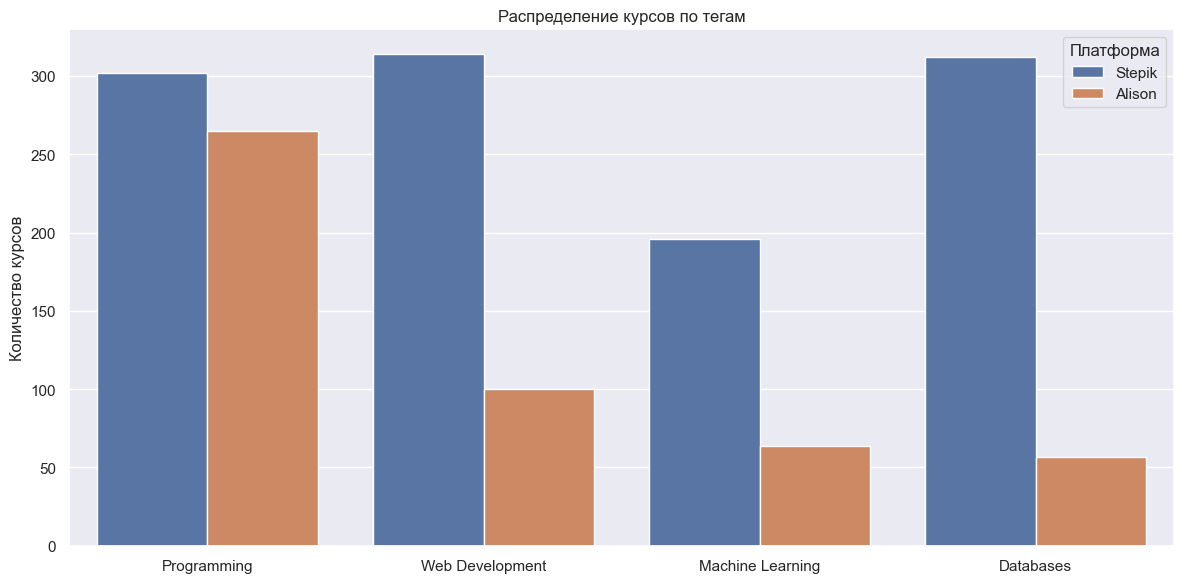

In [19]:
tag_counts.tag = pd.Categorical(tag_counts.tag, categories=tags_en, ordered=True)
plt.figure(figsize=(12, 6))
sns.barplot(tag_counts, x="tag", y="count", hue="platform", order=tags_en).set(
    title="Распределение курсов по тегам",
    xlabel="", ylabel="Количество курсов"
)
plt.legend(title="Платформа")
plt.tight_layout()

### Количество учащихся `learners_count`

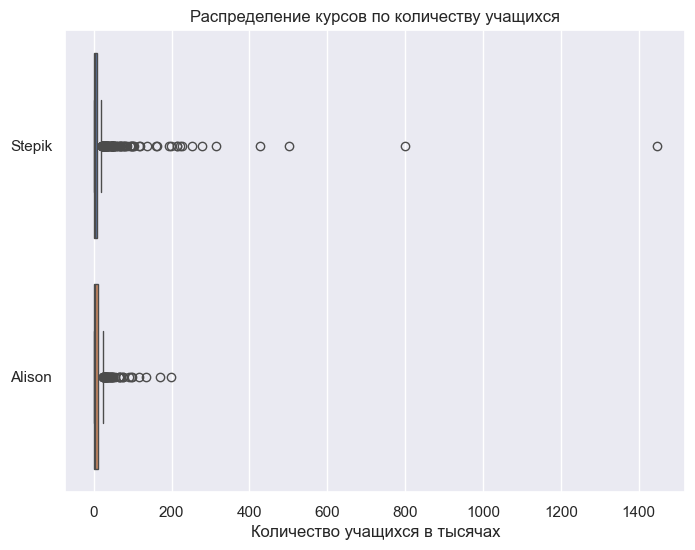

In [20]:
plt.figure(figsize=(8, 6))
sns.boxplot(courses, x="learners_count", y="platform", hue="platform").set(
    title="Распределение курсов по количеству учащихся",
    xlabel="Количество учащихся в тысячах", ylabel="",
    xticks=range(0, 1_400_001, 200_000), xticklabels=range(0, 1401, 200)
);

In [21]:
courses[courses.learners_count > 400_000]

,url,tag_programming,tag_web_development,tag_machine_learning,tag_databases,platform,title,summary,language,difficulty,learners_count,price,certificate,authors,rating,reviews_count
528,https://stepik.org/course/363/,1,1,0,0,Stepik,Введение в программирование (C++),Основы программирования на C++ на примере множ...,ru,None,427519,-,Certificate,Академия Яндекса;Высшая школа экономики (НИУ ВШЭ),4.756545,3056
564,https://stepik.org/course/58852/,1,1,1,1,Stepik,"""Поколение Python"": курс для начинающих",​В курсе рассказывается об основных типах данн...,ru,easy,1447481,-,Certificate,"Тимур 🐍 Гуев;Благотворительный фонд ""Айкью Опш...",4.965999,24058
568,https://stepik.org/course/63054/,1,0,1,1,Stepik,Интерактивный тренажер по SQL,В курсе большинство шагов — это практические з...,ru,easy,501039,-,Certificate,Дальневосточный федеральный университет,4.934341,4630
573,https://stepik.org/course/67/,1,1,0,1,Stepik,Программирование на Python,Курс посвящен базовым понятиям и элементам язы...,ru,None,799137,-,Certificate,Bioinformatics Institute,4.678748,10512


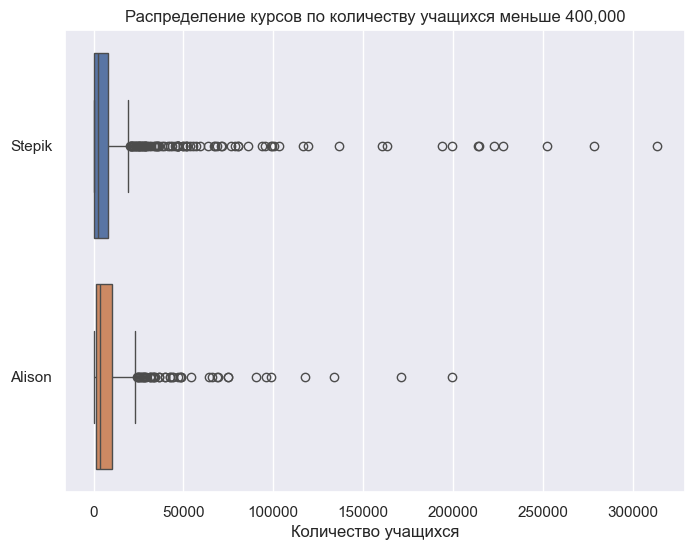

In [22]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    courses[courses.learners_count < 400_000],
    x="learners_count", y="platform", hue="platform"
).set(
    title="Распределение курсов по количеству учащихся меньше 400,000",
    xlabel="Количество учащихся", ylabel=""
);

### Рейтинг `rating`

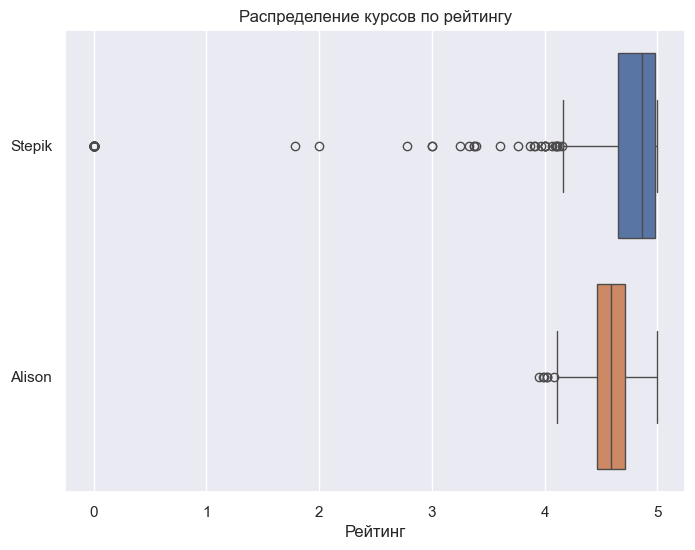

In [23]:
plt.figure(figsize=(8, 6))
sns.boxplot(courses, x="rating", y="platform", hue="platform").set(
    title="Распределение курсов по рейтингу", xlabel="Рейтинг", ylabel=""
);

In [24]:
print(f"Количество курсов с рейтингом 0: {len(courses[courses.rating == 0])}")
print(f"Количество курсов с рейтингом от 0 до 3.9: {len(courses[(courses.rating > 0) & (courses.rating < 3.9)])}")

Количество курсов с рейтингом 0: 46
Количество курсов с рейтингом от 0 до 3.9: 13


### Количество отзывов `reviews_count`

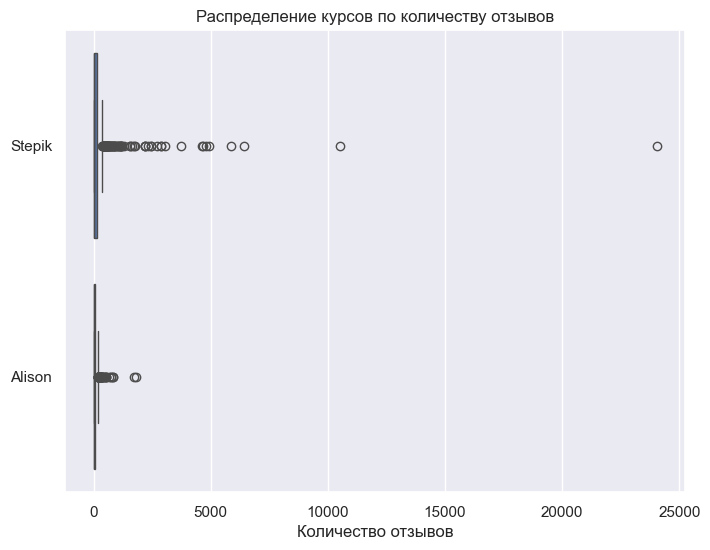

In [25]:
plt.figure(figsize=(8, 6))
sns.boxplot(courses, x="reviews_count", y="platform", hue="platform").set(
    title="Распределение курсов по количеству отзывов",
    xlabel="Количество отзывов", ylabel=""
);

In [26]:
courses[courses.reviews_count > 10_000]

,url,tag_programming,tag_web_development,tag_machine_learning,tag_databases,platform,title,summary,language,difficulty,learners_count,price,certificate,authors,rating,reviews_count
564,https://stepik.org/course/58852/,1,1,1,1,Stepik,"""Поколение Python"": курс для начинающих",​В курсе рассказывается об основных типах данн...,ru,easy,1447481,-,Certificate,"Тимур 🐍 Гуев;Благотворительный фонд ""Айкью Опш...",4.965999,24058
573,https://stepik.org/course/67/,1,1,0,1,Stepik,Программирование на Python,Курс посвящен базовым понятиям и элементам язы...,ru,None,799137,-,Certificate,Bioinformatics Institute,4.678748,10512


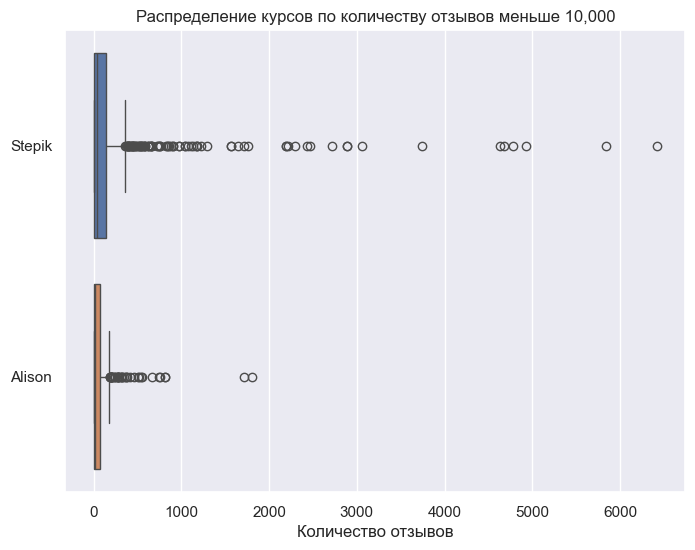

In [27]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    courses[courses.reviews_count < 10_000],
    x="reviews_count", y="platform", hue="platform"
).set(
    title="Распределение курсов по количеству отзывов меньше 10,000",
    xlabel="Количество отзывов", ylabel=""
);

### Стоимость `price`

In [28]:
courses.price.value_counts()

price
0          408
-          376
3500 ₽       6
2999 ₽       6
7900 ₽       5
          ... 
16900 ₽      1
2700 ₽       1
13200 ₽      1
3800 ₽       1
1875 ₽       1
Name: count, Length: 141, dtype: int64

In [29]:
courses.price = courses.price.replace("-", "0").replace(0, "0")
courses.price.value_counts()

price
0          784
3500 ₽       6
2999 ₽       6
7900 ₽       5
3000 ₽       5
          ... 
16500 ₽      1
2700 ₽       1
13200 ₽      1
3800 ₽       1
1875 ₽       1
Name: count, Length: 140, dtype: int64

In [30]:
set("".join(courses.price))

{'0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '\xa0', '₽'}

In [31]:
courses.price = courses.price.str.replace("₽", "").str.replace("\xa0", "")
set("".join(courses.price))

{'0', '1', '2', '3', '4', '5', '6', '7', '8', '9'}

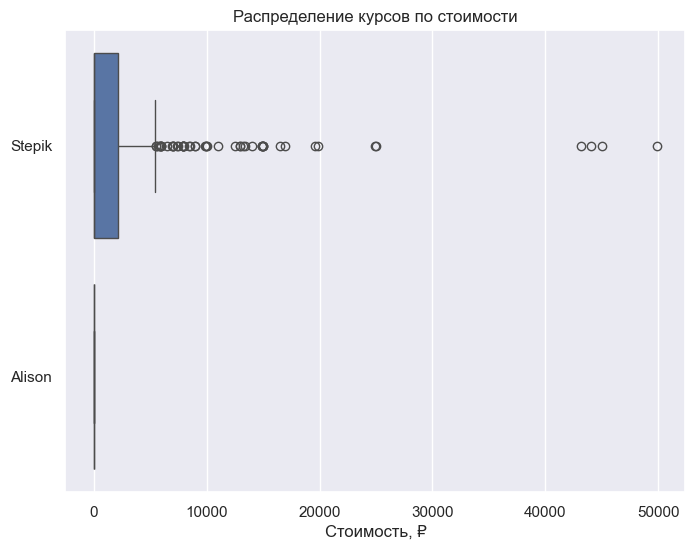

In [32]:
courses.price = courses.price.astype(int)
plt.figure(figsize=(8, 6))
sns.boxplot(courses, x="price", y="platform", hue="platform").set(
    title="Распределение курсов по стоимости",
    xlabel="Стоимость, ₽", ylabel=""
);

In [33]:
courses[courses.price > 40_000]

,url,tag_programming,tag_web_development,tag_machine_learning,tag_databases,platform,title,summary,language,difficulty,learners_count,price,certificate,authors,rating,reviews_count
24,https://stepik.org/course/107779/,1,1,1,1,Stepik,PRO C#. База,"С# разработчик – это человек, который пишет ко...",ru,easy,524,43190,Certificate,Иосиф Дзеранов;IRON PROGRAMMER PRO C#,5.000000,10
141,https://stepik.org/course/170591/,0,1,1,1,Stepik,Проектирование архитектуры и интеграций сервис...,Вы отработаете на практике проектирование архи...,ru,easy,305,44000,Certificate,Глеб Учитель,4.764706,17
436,https://stepik.org/course/245090/,0,0,0,1,Stepik,Стажировка Data Engineer | Осенний поток 2025,Практическая стажировка «Data Engineer с нуля ...,ru,easy,61,44990,Certificate,NovaData.,0.000000,0
563,https://stepik.org/course/58658/,1,0,0,0,Stepik,PRO C#. ООП на практике,Напишем оконные приложения и игры на Windows F...,ru,normal,152,49900,Certificate,Иосиф Дзеранов;IRON PROGRAMMER PRO C#,4.979592,49


### Платформы `platform`

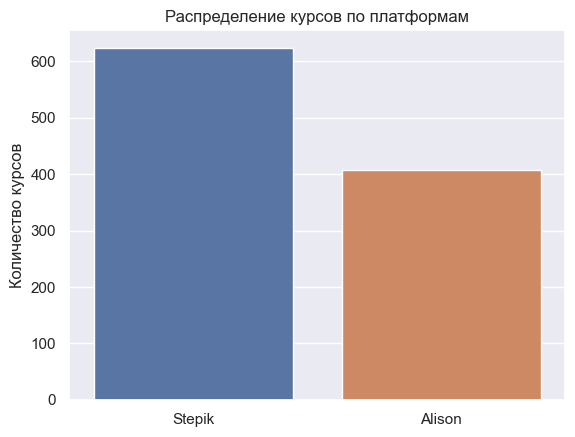

In [34]:
sns.countplot(courses, x="platform", hue="platform").set(
    title="Распределение курсов по платформам", xlabel="", ylabel="Количество курсов"
);

### Языки `language`

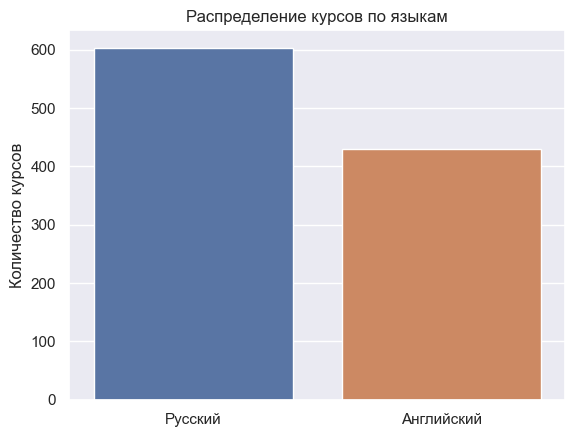

In [35]:
sns.countplot(courses, x="language", hue="language").set(
    title="Распределение курсов по языкам", xlabel="", ylabel="Количество курсов",
    xticks=range(2), xticklabels=["Русский", "Английский"]
);

### Сложность `difficulty`

In [36]:
courses.difficulty = courses.difficulty.map({
    "easy": "Простой", "Beginner Level": "Простой",
    "normal": "Средний", "Intermediate Level": "Средний",
    "hard": "Сложный", "Advanced Level": "Сложный"
}).fillna("Неизвестно")
courses.difficulty.value_counts()

difficulty
Простой       556
Средний       239
Сложный       122
Неизвестно    115
Name: count, dtype: int64

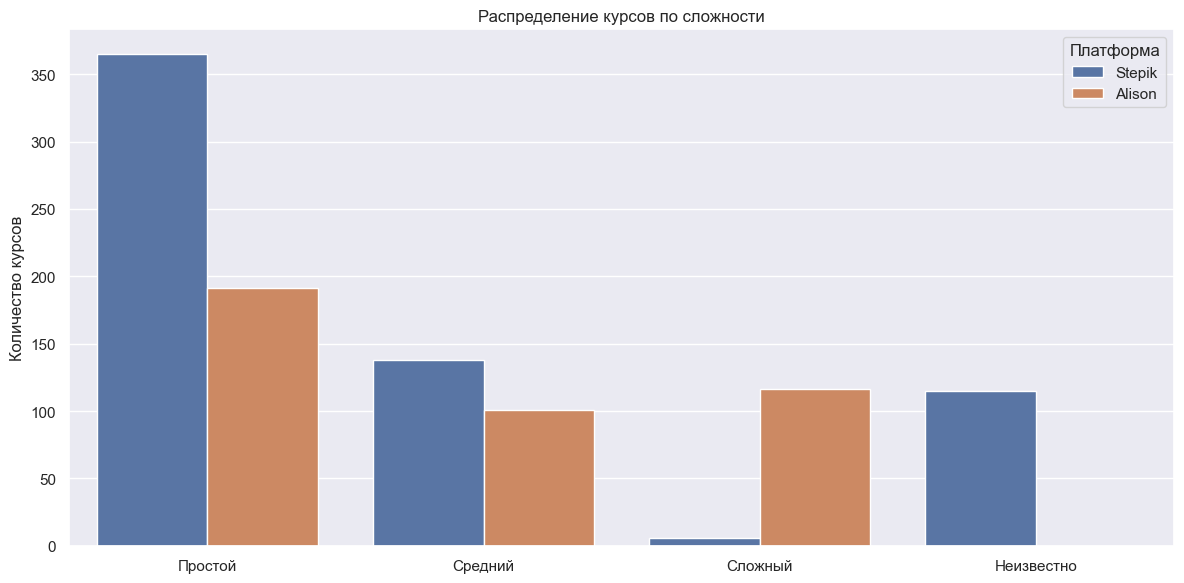

In [37]:
difficulty_order = ["Простой", "Средний", "Сложный", "Неизвестно"]
difficulty_counts = courses.groupby(["difficulty", "platform"]).size().reset_index()
difficulty_counts.columns = ["difficulty", "platform", "count"]
difficulty_counts.difficulty = pd.Categorical(
    difficulty_counts.difficulty,
    categories=difficulty_order,
    ordered=True
)
plt.figure(figsize=(12, 6))
sns.barplot(
    difficulty_counts, x="difficulty", y="count",
    hue="platform", order=difficulty_order
).set(
    title="Распределение курсов по сложности",
    xlabel="", ylabel="Количество курсов"
)
plt.legend(title="Платформа")
plt.tight_layout()

### Сертификаты `certificate`

In [38]:
courses.certificate = courses.certificate.map({
    "Certificate": "Сертификат", "Diploma": "Диплом"
}).fillna("Нет")
courses.certificate.value_counts()

certificate
Сертификат    729
Нет           241
Диплом         62
Name: count, dtype: int64

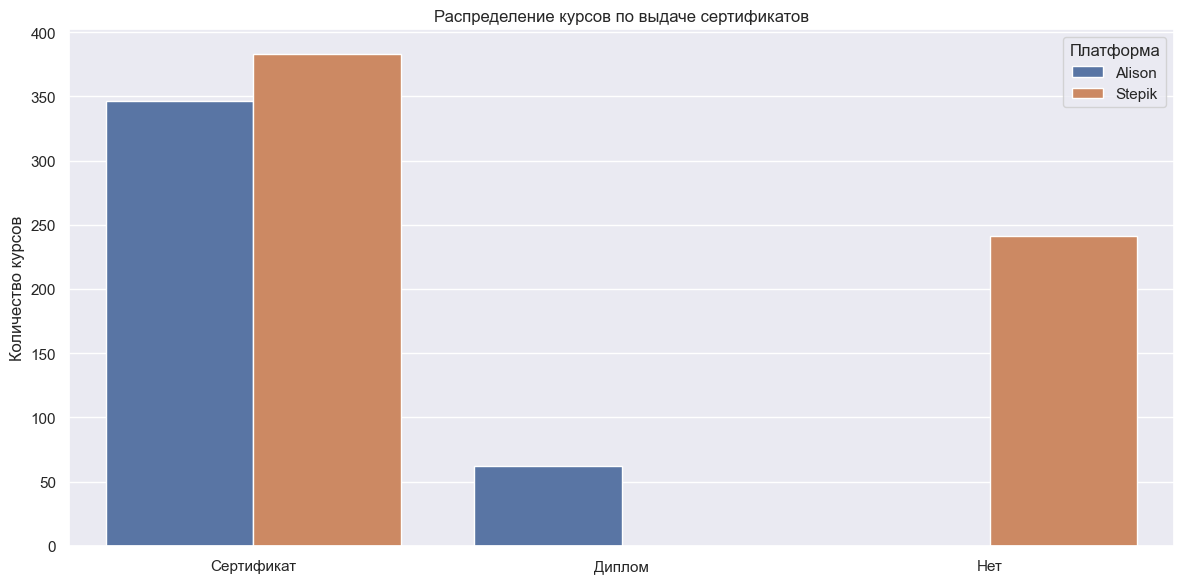

In [39]:
certificate_order = ["Сертификат", "Диплом", "Нет"]
certificate_counts = courses.groupby(["certificate", "platform"]).size().reset_index()
certificate_counts.columns = ["certificate", "platform", "count"]
certificate_counts.certificate = pd.Categorical(
    certificate_counts.certificate,
    categories=certificate_order,
    ordered=True
)
plt.figure(figsize=(12, 6))
sns.barplot(
    certificate_counts, x="certificate", y="count",
    hue="platform", order=certificate_order
).set(
    title="Распределение курсов по выдаче сертификатов",
    xlabel="", ylabel="Количество курсов"
)
plt.legend(title="Платформа")
plt.tight_layout()

### Удаление аномалий и преобразование строк в числа

In [40]:
courses.drop(courses[courses.learners_count > 400_000].index, inplace=True)
courses.drop(courses[courses.price > 40_000].index, inplace=True)
courses.reset_index(drop=True, inplace=True)

courses.platform = courses.platform.map({"Stepik": 0, "Alison": 1})
courses.language = courses.language.map({"ru": 0, "en": 1})
courses.difficulty = courses.difficulty.map({
    "Неизвестно": 0, "Простой": 1, "Средний": 2, "Сложный": 3
})
courses.certificate = courses.certificate.map({"Нет": 0, "Сертификат": 1, "Диплом": 2})

courses

,url,tag_programming,tag_web_development,tag_machine_learning,tag_databases,platform,title,summary,language,difficulty,learners_count,price,certificate,authors,rating,reviews_count
0,https://stepik.org/course/100056/,1,0,0,1,0,ЕГЭ Информатика,"Пройдя данный курс, вы с нуля изучите всю теор...",0,1,47027,0,1,PRO100 ЕГЭ,4.972973,111
1,https://stepik.org/course/100076/,0,0,1,0,0,Введение в искусственные нейронные сети,В курсе даётся элементарное введение в теорию ...,0,1,17625,0,1,Ольга Хоменко;Артём Шевляков;ОмГТУ,4.961938,289
2,https://stepik.org/course/100208/,1,0,0,0,0,Go (Golang) - первое знакомство,Это курс по языку программирования Go (Golang)...,0,0,25085,0,1,Игорь Лютый,4.868020,1182
3,https://stepik.org/course/100210/,0,0,0,1,0,ClickHouse для аналитика,ClickHouse это одна из самых быстро развивающи...,0,0,1225,3990,1,Дмитрий Новиков,4.857143,21
4,https://stepik.org/course/100575/,1,1,0,0,0,"""Поколение Python"": алгоритмы и структуры данн...","Курс включает такие темы, как анализ алгоритмо...",0,1,2049,7900,1,Тимур 🐍 Гуев;Поколение Python,5.000000,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1019,https://alison.com/course/web-development-with...,1,1,0,0,1,Web Development with HTML and CSS for Beginners,Are you a web-design beginner with no prior kn...,1,1,95852,0,1,Zenva,4.615221,740
1020,https://alison.com/course/web-development-with...,0,1,0,0,1,"Web Development With jQuery, Ajax and JSON",All businesses today require excellent web des...,1,3,3198,0,1,Stone River eLearning,4.216722,13
1021,https://alison.com/course/webvr-programming-us...,1,1,0,0,1,WebVR Programming Using A -Frame Framework,We have designed this course on WebVR Programm...,1,3,814,0,1,Sonar Systems,5.000000,5
1022,https://alison.com/course/wordpress-fundamenta...,0,1,0,0,1,WordPress Fundamentals - Content Management Sy...,This WordPress course covers all the important...,1,1,8987,0,1,Digital Partner,4.495391,91


## Текстовые признаки

In [41]:
courses.summary = courses.summary.fillna("")
courses[courses.isna().any(axis=1)]

,url,tag_programming,tag_web_development,tag_machine_learning,tag_databases,platform,title,summary,language,difficulty,learners_count,price,certificate,authors,rating,reviews_count


In [48]:
def normalize_text(text):
    tokenizer = WordPunctTokenizer()
    morph = MorphAnalyzer()

    stop_words = set(stopwords.words("russian") + stopwords.words("english"))
    stop_words.update({
        "курс", "обучение", "программа", "урок", "занятие", "лекция",
        "материал", "видео", "онлайн", "бесплатно", "платно",
        "основа", "введение", "базовый", "продвинутый", "advanced",
        "basic", "tutorial", "guide", "introduction", "fundamentals"
    })
    
    text = text.lower().strip()
    text = re.sub(r"[^\w\s\+\#\.\-]", " ", text)
    
    words = []
    for word in tokenizer.tokenize(text):
        if re.search(r"[а-яё]", word):
            word = morph.normal_forms(word)[0]
            word = word.replace("ё", "е")
            if word not in stop_words and len(word) >= 2:
                words.append(word)
        
        elif re.search(r"[a-z]", word):
            word = word.lower()
            if word not in stop_words:
                words.append(word)
    
    return " ".join(words)

In [47]:
course_title_vec = TfidfVectorizer(
    lowercase=False, preprocessor=normalize_text, tokenizer=None,
    stop_words=None, ngram_range=(1, 2), min_df=2, max_features=100
)
course_title_csr = course_title_vec.fit_transform(courses.title)
course_title_freq = pd.Series(
    course_title_csr.sum(axis=0).A1.tolist(),
    course_title_vec.get_feature_names_out()
)
course_title_freq.sort_values(ascending=False, inplace=True)
course_title_freq.head(10)

python              83.639077
programming         46.581666
diploma             38.840072
sql                 33.735672
программирование    31.716703
javascript          26.633078
начинающий          26.108918
data                26.010491
нуль                24.544333
using               23.678239
dtype: float64

In [49]:
course_summary_vec = TfidfVectorizer(
    lowercase=False, preprocessor=normalize_text, tokenizer=None,
    stop_words=None, ngram_range=(1, 2), min_df=2, max_features=100
)
course_summary_csr = course_summary_vec.fit_transform(courses.summary)
course_summary_freq = pd.Series(
    course_summary_csr.sum(axis=0).A1.tolist(),
    course_summary_vec.get_feature_names_out()
)
course_summary_freq.sort_values(ascending=False, inplace=True)
course_summary_freq.head(10)

course              92.750599
python              61.975519
язык                53.744981
data                51.364833
данные              51.131536
программирование    49.703205
learn               48.699213
programming         47.356283
задача              45.173439
работа              42.221423
dtype: float64

In [50]:
def tokenize_authors(authors_list):
    return [author for author in authors_list.split(';')]


course_authors_vec = CountVectorizer(
    lowercase=False, tokenizer=tokenize_authors, token_pattern=None,
    max_features=100, binary=True
)
course_authors_csr = course_authors_vec.fit_transform(courses.authors)
course_authors_freq = pd.Series(
    course_authors_csr.sum(axis=0).A1.tolist(),
    course_authors_vec.get_feature_names_out()
)
course_authors_freq.sort_values(ascending=False, inplace=True)
course_authors_freq.head(10)

Stone River eLearning            43
NPTEL                            38
Workforce Academy Partnership    37
Ashraf Said AlMadhoun            35
Pragmatic Programmer             28
YouAccel Training                26
Channel 9                        24
Sonar Systems                    22
Laurence Svekis ✔                19
Александр Куликов                14
dtype: int64

# Подготовка набора данных к обучению

In [51]:
(y_true := courses.learners_count)

0       47027
1       17625
2       25085
3        1225
4        2049
        ...  
1019    95852
1020     3198
1021      814
1022     8987
1023     1092
Name: learners_count, Length: 1024, dtype: int64

In [52]:
(X := courses.drop(columns=["url", "title", "summary", "authors", "learners_count"]))

,tag_programming,tag_web_development,tag_machine_learning,tag_databases,platform,language,difficulty,price,certificate,rating,reviews_count
0,1,0,0,1,0,0,1,0,1,4.972973,111
1,0,0,1,0,0,0,1,0,1,4.961938,289
2,1,0,0,0,0,0,0,0,1,4.868020,1182
3,0,0,0,1,0,0,0,3990,1,4.857143,21
4,1,1,0,0,0,0,1,7900,1,5.000000,53
...,...,...,...,...,...,...,...,...,...,...,...
1019,1,1,0,0,1,1,1,0,1,4.615221,740
1020,0,1,0,0,1,1,3,0,1,4.216722,13
1021,1,1,0,0,1,1,3,0,1,5.000000,5
1022,0,1,0,0,1,1,1,0,1,4.495391,91


In [53]:
def get_vectorized_columns(vec, csr, column_name):
    columns = vec.get_feature_names_out()
    for i in range(len(columns)):
        word = columns[i].replace("-", "_").replace(" ", "_")
        columns[i] = f"course_{column_name}_{word}"
    return pd.DataFrame(csr.toarray(), columns=columns)


X = pd.concat([
    X,
    get_vectorized_columns(course_title_vec, course_title_csr, "title"),
    get_vectorized_columns(course_summary_vec, course_summary_csr, "summary"),
    get_vectorized_columns(course_authors_vec, course_authors_csr, "authors")
], axis=1)

X

,tag_programming,tag_web_development,tag_machine_learning,tag_databases,platform,language,difficulty,price,certificate,rating,...,course_authors_Ольга_Хоменко,course_authors_ОмГТУ,course_authors_Павел_Тарасов,course_authors_Павел_Хошев,course_authors_Поколение_Python,course_authors_Сергей_Балакирев,course_authors_Тимур_🐍_Гуев,course_authors_Томский_государственный_университет,course_authors_Школа_глубокого_обучения_МФТИ,course_authors_♥️_Никита_Шультайс
0,1,0,0,1,0,0,1,0,1,4.972973,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,1,0,1,4.961938,...,1,1,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,1,4.868020,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,3990,1,4.857143,...,0,0,0,0,0,0,0,0,0,0
4,1,1,0,0,0,0,1,7900,1,5.000000,...,0,0,0,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1019,1,1,0,0,1,1,1,0,1,4.615221,...,0,0,0,0,0,0,0,0,0,0
1020,0,1,0,0,1,1,3,0,1,4.216722,...,0,0,0,0,0,0,0,0,0,0
1021,1,1,0,0,1,1,3,0,1,5.000000,...,0,0,0,0,0,0,0,0,0,0
1022,0,1,0,0,1,1,1,0,1,4.495391,...,0,0,0,0,0,0,0,0,0,0


In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y_true, test_size=0.3, random_state=0)

# Обучение моделей

## Линейная регрессия

In [55]:
line_model = LinearRegression()
line_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
print("Линейная регрессия")
print(f"Train: {r2_score(y_train, line_model.predict(X_train))}")
print(f"Test: {r2_score(y_test, line_model.predict(X_test))}")

Линейная регрессия
Train: 0.8247450203412886
Test: 0.4087586195762334


## Гребневая регрессия

In [57]:
ridge_model = RidgeCV()
ridge_model.fit(X_train, y_train)

,alphas,"(0.1, ...)"
,fit_intercept,True
,scoring,None
,cv,None
,gcv_mode,None
,store_cv_results,False
,alpha_per_target,False


In [58]:
print("Гребневая регрессия")
print(f"Train: {r2_score(y_train, ridge_model.predict(X_train))}")
print(f"Test: {r2_score(y_test, ridge_model.predict(X_test))}")

Гребневая регрессия
Train: 0.8107812411385507
Test: 0.5351104328869136


## Лассо-регрессия

In [59]:
lasso_model = LassoCV()
lasso_model.fit(X_train, y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,None
,verbose,False
,n_jobs,None


In [60]:
print("Лассо-регрессия")
print(f"Train: {r2_score(y_train, lasso_model.predict(X_train))}")
print(f"Test: {r2_score(y_test, lasso_model.predict(X_test))}")

Лассо-регрессия
Train: 0.5909431548632031
Test: 0.4907721858874121


## ElasticNet

In [61]:
elastic_net_model = ElasticNetCV()
elastic_net_model.fit(X_train, y_train)

,l1_ratio,0.5
,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,cv,None
,copy_X,True
,verbose,0


In [62]:
print("ElasticNet")
print(f"Train: {r2_score(y_train, elastic_net_model.predict(X_train))}")
print(f"Test: {r2_score(y_test, elastic_net_model.predict(X_test))}")

ElasticNet
Train: 0.5899747590114834
Test: 0.4928802406535706


## Градиентный бустинг

In [63]:
boosting_model = HistGradientBoostingRegressor()
boosting_model.fit(X_train, y_train)

,loss,'squared_error'
,quantile,None
,learning_rate,0.1
,max_iter,100
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


In [64]:
print("Градиентный бустинг")
print(f"Train: {r2_score(y_train, boosting_model.predict(X_train))}")
print(f"Test: {r2_score(y_test, boosting_model.predict(X_test))}")

Градиентный бустинг
Train: 0.8087190841911042
Test: 0.5598703073664106


## Случайный лес

In [65]:
forest_model = RandomForestRegressor(random_state=0)
forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
print("Случайный лес")
print(f"Train: {r2_score(y_train, forest_model.predict(X_train))}")
print(f"Test: {r2_score(y_test, forest_model.predict(X_test))}")

Случайный лес
Train: 0.9374778331694597
Test: 0.6126018506116988
